# Animal NER & Detection Pipeline

In [1]:
import sys
sys.path.append("..")

from NER.inference import AnimalNER
from ImDet.inference import AnimalDetector
from pipeline import AnimalPipeline
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
import numpy as np

d:\VSCode projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
NER_MODEL_PATH  = "./NER/checkpoints/ner_model"
YOLO_MODEL_PATH = "./ImDet/runs/detect/checkpoints/yolo/weights/weights/best.pt"

pipeline = AnimalPipeline(
    ner_model_path=NER_MODEL_PATH,
    yolo_model_path=YOLO_MODEL_PATH,
    conf_threshold=0.25
)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4588.32it/s]

Loaded model with labels: ['O', 'B-ANIMAL', 'I-ANIMAL']


## NER Standalone Demo

In [3]:
ner = AnimalNER(NER_MODEL_PATH)

texts = [
    "Is there a sparrow on the screen?",
    "I think I see a lizard here.",
    "Have you seen a frog on that picture?",
]

for text in texts:
    entities = ner.predict(text)
    animals  = [e['entity'] for e in entities]
    print(f"Text: '{text}'")
    print(f"Entities: {animals}\n")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4805.61it/s]


Loaded model with labels: ['O', 'B-ANIMAL', 'I-ANIMAL']
Text: 'Is there a sparrow on the screen?'
Entities: ['sparrow']

Text: 'I think I see a lizard here.'
Entities: ['lizard']

Text: 'Have you seen a frog on that picture?'
Entities: ['frog']



## YOLO Standalone Demo

In [4]:
detector = AnimalDetector(YOLO_MODEL_PATH, conf_threshold=0.25)

test_images = [
    r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Starfish\138226651ff65386.jpg",
    r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Sparrow\4d52b2c01941035e.jpg",
    r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Monkey\1d30e66d44487220.jpg",
]

for img_path in test_images:
    detected = detector.predict(img_path)
    print(f"{img_path}: {detected}")

D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Starfish\138226651ff65386.jpg: Starfish
D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Sparrow\4d52b2c01941035e.jpg: Sparrow
D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Monkey\1d30e66d44487220.jpg: Monkey


## Visualize YOLO Detections

In [5]:
def show_detections(image_path, model_path, conf=0.25):
    model = YOLO(model_path)
    results = model(image_path, conf=conf, verbose=False)
    img = Image.open(image_path)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            cls  = result.names[int(box.cls)]
            conf = float(box.conf)
            rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, f"{cls} {conf:.2f}", color='red', fontsize=10)

    ax.axis('off')

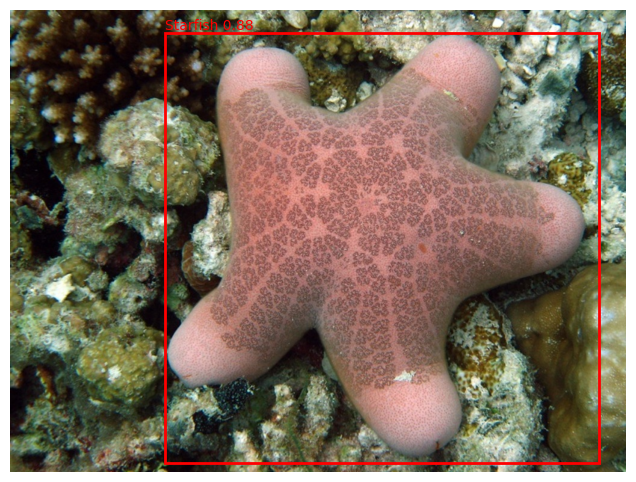

In [6]:
show_detections(r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Starfish\138226651ff65386.jpg", YOLO_MODEL_PATH)

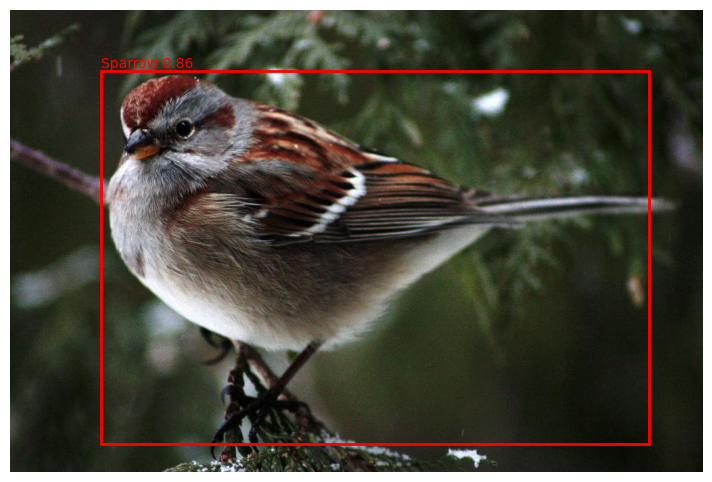

In [7]:
show_detections(r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Sparrow\4d52b2c01941035e.jpg", YOLO_MODEL_PATH)

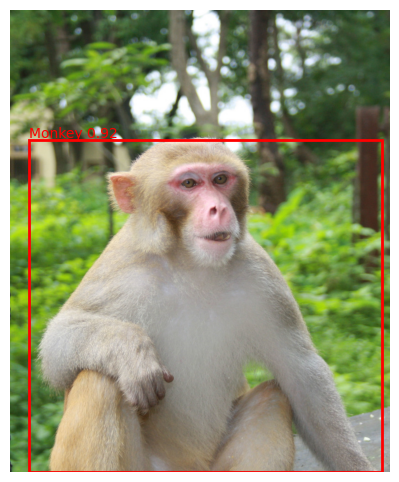

In [8]:
show_detections(r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Monkey\1d30e66d44487220.jpg", YOLO_MODEL_PATH)

## Full Pipeline: True, False cases

In [9]:
true_cases = [
    ("I think I see a lizard here", r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Lizard\1dcf37ffd5ec1842.jpg"),
    ("What a beautiful sparrow", r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Sparrow\4d52b2c01941035e.jpg"),
    ("Have you seen a frog on that picture?", r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Frog\3c8254187041e3f0.jpg")
]

for text, img_path in true_cases:
    result = pipeline.run(text=text, image_path=img_path)
    status = "Yes" if result else "No"
    print(f"{status} [{result}]  '{text}'")

[Pipeline] NER extracted: ['lizard']
[Pipeline] YOLO detected: Lizard
Yes [True]  'I think I see a lizard here'
[Pipeline] NER extracted: ['sparrow']
[Pipeline] YOLO detected: Sparrow
Yes [True]  'What a beautiful sparrow'
[Pipeline] NER extracted: ['frog']
[Pipeline] YOLO detected: Frog
Yes [True]  'Have you seen a frog on that picture?'


In [10]:
false_cases = [
    ("I think I see a cheetah here", r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Lizard\1dcf37ffd5ec1842.jpg"),
    ("Is not this owl beautiful?", r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Deer\4d9d873f1d080e6a.jpg"),
    ("Have you seen a fox on that picture?", r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Frog\3c8254187041e3f0.jpg"),
]

for text, img_path in false_cases:
    result = pipeline.run(text=text, image_path=img_path)
    status = "Yes" if result else "No"
    print(f"{status} [{result}]  '{text}'")

[Pipeline] NER extracted: ['cheetah']
[Pipeline] YOLO detected: Lizard
No [False]  'I think I see a cheetah here'
[Pipeline] NER extracted: ['owl']
[Pipeline] YOLO detected: Deer
No [False]  'Is not this owl beautiful?'
[Pipeline] NER extracted: ['fox']
[Pipeline] YOLO detected: Frog
No [False]  'Have you seen a fox on that picture?'


## Edge Cases

### No animal in text

In [11]:
result = pipeline.run(
    text="I can feel sunrays on my skin!",
    image_path=r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Deer\6ef20d09b3cfff60.jpg"
)
print(f"No animal in text: {result}")

[Pipeline] NER found nothing in: 'I can feel sunrays on my skin!'
No animal in text: False


### Animal in text but blank/noise image

In [12]:
noise = Image.fromarray(np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8))
noise.save("samples/noise.jpg")

result = pipeline.run(
    text="There is a giraffe in the picture",
    image_path="samples/noise.jpg"
)
print(f"Noise image: {result}")

[Pipeline] NER extracted: ['giraffe']
[Pipeline] YOLO detected nothing
Noise image: False


### Empty text

In [13]:
for text in ["", "   "]:
    result = pipeline.run(text=text, image_path=r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Deer\06b9676c4cd5f96b.jpg")
    print(f"Input {text!r} - {result}")

[Pipeline] NER found nothing in: ''
Input '' - False
[Pipeline] NER found nothing in: '   '
Input '   ' - False


### Known limitation: partial animal names

In [14]:
result = pipeline.run(
    text="I see a bear in the photo.",
    image_path=r"D:\VSCode projects\MNIST-NERImClass\NERImDet\data\test\Brown bear\c7b126470663c077.jpg"
)
print(f"'bear' vs 'Brown bear' - {result}")

[Pipeline] NER extracted: ['bear']
[Pipeline] YOLO detected: Bear
'bear' vs 'Brown bear' - True
